In [ ]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.utils import resample
import eli5
import warnings
warnings.filterwarnings('ignore')

In [ ]:
employee_df =  pd.read_csv('watson_healthcare.csv') #Reading the dataset
employee_df.head()

,EmployeeID,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,Shift,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1313919,41,No,Travel_Rarely,1102,Cardiology,1,2,Life Sciences,1,...,1,80,0,8,0,1,6,4,0,5
1,1200302,49,No,Travel_Frequently,279,Maternity,8,1,Life Sciences,1,...,4,80,1,10,3,3,10,7,1,7
2,1060315,37,Yes,Travel_Rarely,1373,Maternity,2,2,Other,1,...,2,80,0,7,3,3,0,0,0,0
3,1272912,33,No,Travel_Frequently,1392,Maternity,3,4,Life Sciences,1,...,3,80,0,8,3,3,8,7,3,0
4,1414939,27,No,Travel_Rarely,591,Maternity,2,1,Medical,1,...,4,80,1,6,3,3,2,2,2,2


In [ ]:
employee_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1676 entries, 0 to 1675
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   EmployeeID                1676 non-null   int64 
 1   Age                       1676 non-null   int64 
 2   Attrition                 1676 non-null   object
 3   BusinessTravel            1676 non-null   object
 4   DailyRate                 1676 non-null   int64 
 5   Department                1676 non-null   object
 6   DistanceFromHome          1676 non-null   int64 
 7   Education                 1676 non-null   int64 
 8   EducationField            1676 non-null   object
 9   EmployeeCount             1676 non-null   int64 
 10  EnvironmentSatisfaction   1676 non-null   int64 
 11  Gender                    1676 non-null   object
 12  HourlyRate                1676 non-null   int64 
 13  JobInvolvement            1676 non-null   int64 
 14  JobLevel                

In [ ]:
employee_df.describe()

,EmployeeID,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,Shift,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1.676000e+03,1676.000000,1676.000000,1676.000000,1676.000000,1676.0,1676.000000,1676.000000,1676.000000,1676.000000,...,1676.000000,1676.0,1676.000000,1676.000000,1676.000000,1676.000000,1676.000000,1676.000000,1676.000000,1676.000000
mean,1.456796e+06,36.866348,800.557876,9.221957,2.907518,1.0,2.714797,65.470167,2.724940,2.066826,...,2.718377,80.0,0.806086,11.338902,2.805489,2.766110,7.033413,4.264916,2.200477,4.135442
std,2.487486e+05,9.129126,401.594438,8.158118,1.025835,0.0,1.097534,20.207572,0.714121,1.113423,...,1.078162,0.0,0.855527,7.834996,1.288431,0.702369,6.098991,3.627456,3.229587,3.559662
min,1.025177e+06,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.235832e+06,30.000000,465.000000,2.000000,2.000000,1.0,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,1.464606e+06,36.000000,796.500000,7.000000,3.000000,1.0,3.000000,65.500000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1.667992e+06,43.000000,1157.000000,14.000000,4.000000,1.0,4.000000,83.000000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000
max,1.886378e+06,60.000000,1499.000000,29.000000,5.000000,1.0,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [ ]:
employee_df.isna().sum()

EmployeeID                  0
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
Shift                       0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [ ]:
employee_df.duplicated().sum()

0

In [ ]:
employee_df.isnull().sum()

EmployeeID                  0
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
Shift                       0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [ ]:
employee_df['JobRole'].value_counts()

Nurse             822
Other             534
Therapist         189
Administrative    115
Admin              16
Name: JobRole, dtype: int64

In [ ]:
employee_df['Attrition'].value_counts()

No     1477
Yes     199
Name: Attrition, dtype: int64

In [ ]:
employee_df['BusinessTravel'].value_counts()

Travel_Rarely        1184
Travel_Frequently     320
Non-Travel            172
Name: BusinessTravel, dtype: int64

In [ ]:
employee_df['Department'].value_counts()

Maternity     796
Cardiology    531
Neurology     349
Name: Department, dtype: int64

In [ ]:
employee_df['EducationField'].value_counts()

Life Sciences       697
Medical             524
Marketing           189
Technical Degree    149
Other                88
Human Resources      29
Name: EducationField, dtype: int64

In [ ]:
employee_df['Gender'].value_counts()

Male      998
Female    678
Name: Gender, dtype: int64

In [ ]:
employee_df['MaritalStatus'].value_counts()

Married     777
Single      522
Divorced    377
Name: MaritalStatus, dtype: int64

In [ ]:
employee_df['Over18'].value_counts()

Y    1676
Name: Over18, dtype: int64

In [ ]:
employee_df['OverTime'].value_counts()

No     1200
Yes     476
Name: OverTime, dtype: int64

<AxesSubplot:>

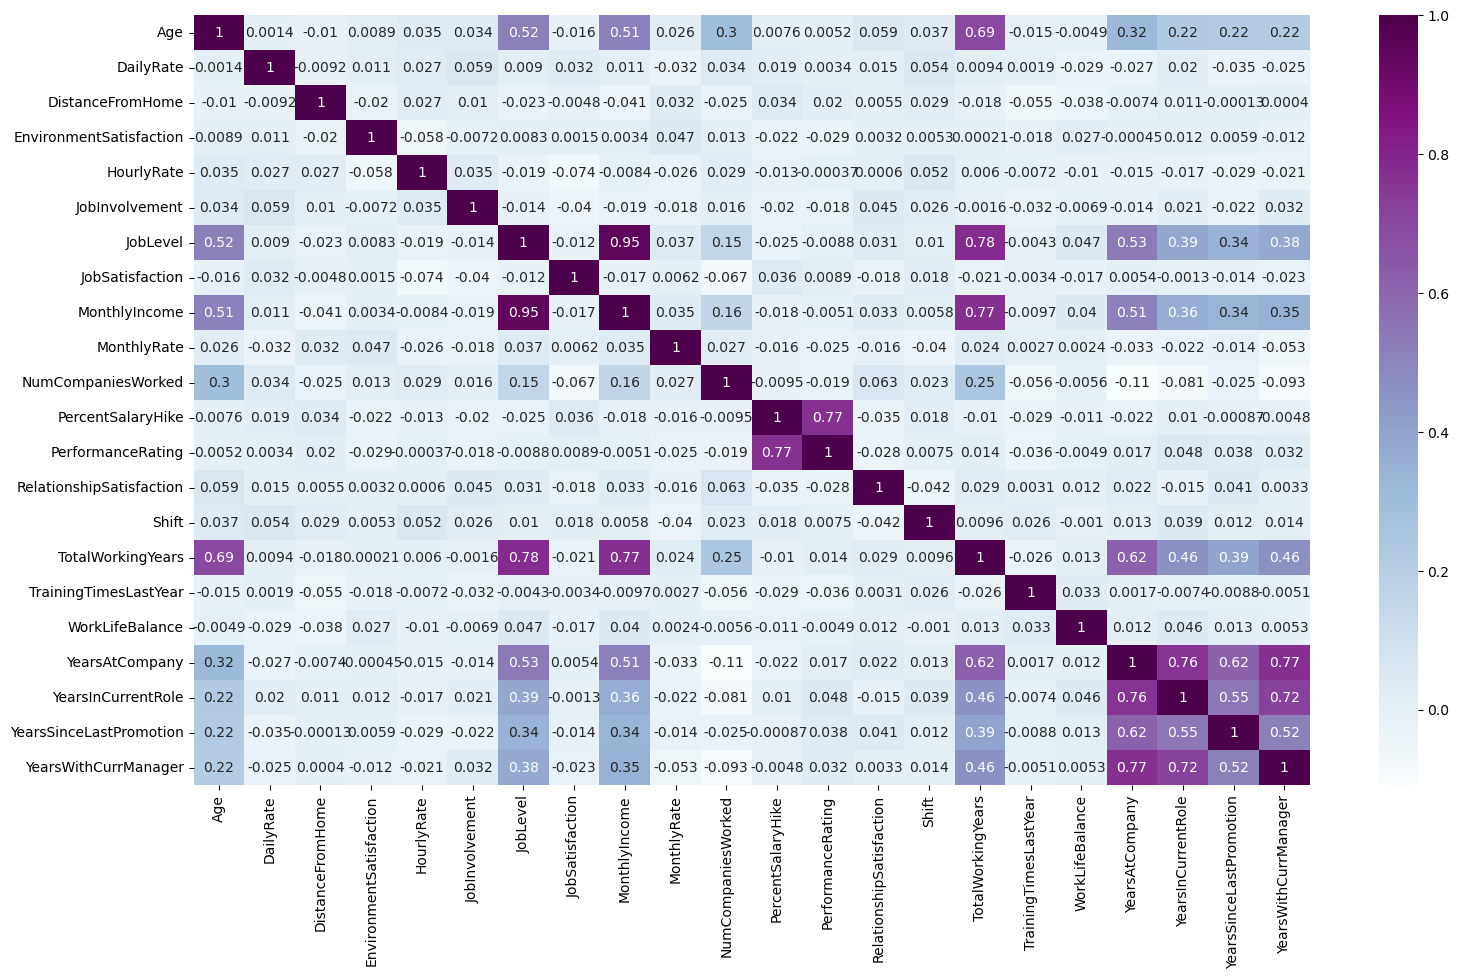

In [ ]:
correlation_df = employee_df.drop(["EmployeeID","Department","Education","EducationField","EmployeeCount","Gender","Attrition","Over18",
                   "OverTime","JobRole","MaritalStatus","BusinessTravel","StandardHours"], axis=1)
f, ax = plt.subplots(figsize=(18,10))
sb.heatmap(correlation_df.corr(method='pearson'),annot=True,cmap='BuPu')

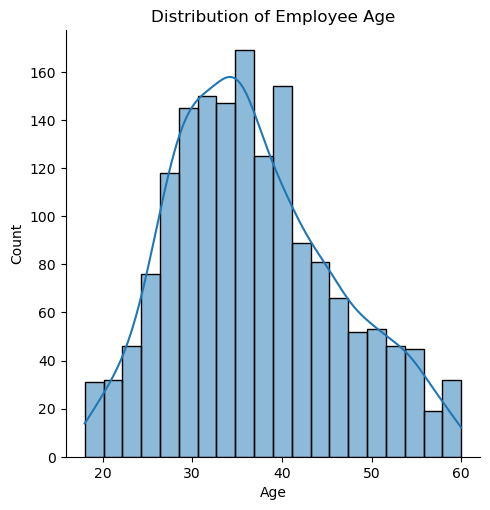

count    1676.000000
mean       36.866348
std         9.129126
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: Age, dtype: float64

In [ ]:
sb.displot(employee_df["Age"], kde=True)
plt.title("Distribution of Employee Age")
plt.show()
employee_df["Age"].describe()

count    1676.000000
mean        7.033413
std         6.098991
min         0.000000
25%         3.000000
50%         5.000000
75%        10.000000
max        40.000000
Name: YearsAtCompany, dtype: float64

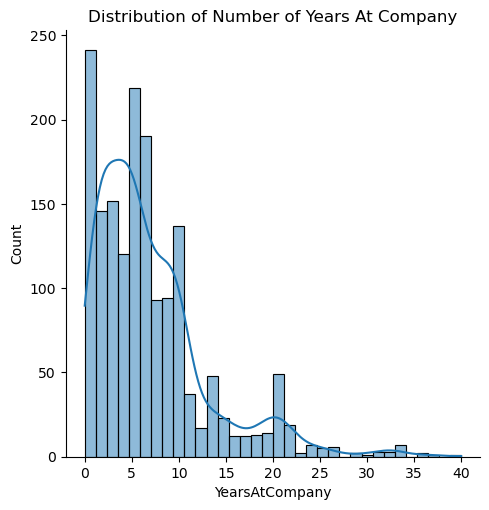

In [ ]:
sb.displot(employee_df["YearsAtCompany"], kde=True)
plt.title('Distribution of Number of Years At Company')
employee_df['YearsAtCompany'].describe()

Text(0.5, 1.0, 'Average Monthly Income by Job Level')

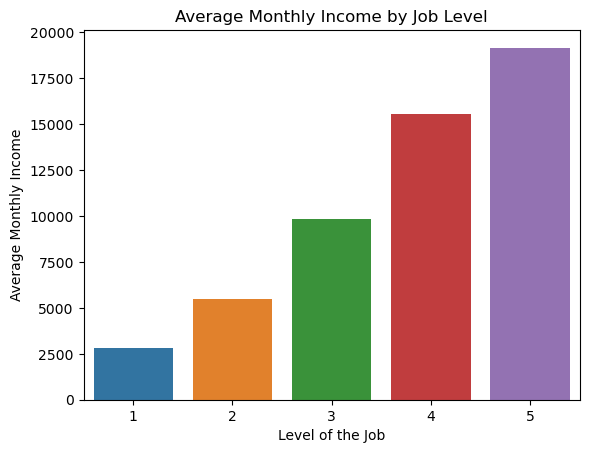

In [ ]:
employee_income= employee_df[["JobLevel","MonthlyIncome"]].groupby(by="JobLevel").mean().reset_index()
sb.barplot(data=employee_income, x="JobLevel", y="MonthlyIncome")
plt.xlabel('Level of the Job')
plt.ylabel('Average Monthly Income')
plt.title("Average Monthly Income by Job Level")

<AxesSubplot:xlabel='YearsAtCompany', ylabel='MonthlyIncome'>

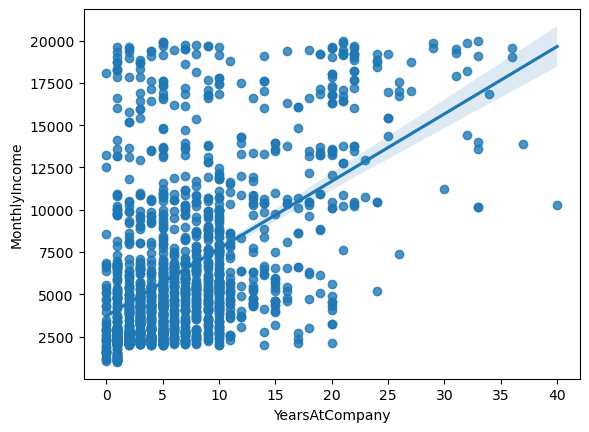

In [ ]:
sb.regplot(data=employee_df, x="YearsAtCompany", y="MonthlyIncome")

In [ ]:
attr_dictionary = {
    'Yes': 1,
    'No': 0
}

employee_df['AttritionNum'] = employee_df.Attrition.map(attr_dictionary)

(array([896., 425., 119.,  23.,  14.]),
 array([ 0.,  8., 16., 24., 32., 40.]),
 <BarContainer object of 5 artists>)

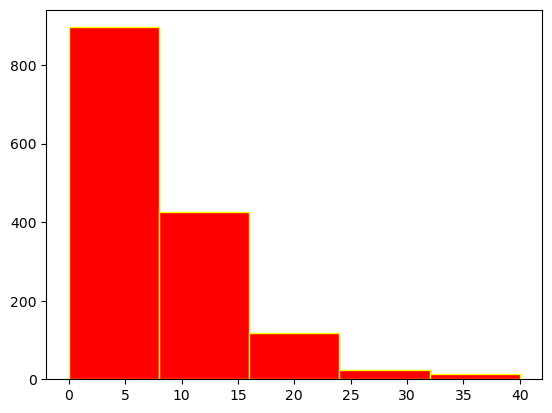

In [ ]:
plt.hist(employee_df[employee_df['AttritionNum']==0]['YearsAtCompany'], color='red',edgecolor='yellow',bins=5)

(array([162.,  31.,   3.,   2.,   1.]),
 array([ 0. ,  6.2, 12.4, 18.6, 24.8, 31. ]),
 <BarContainer object of 5 artists>)

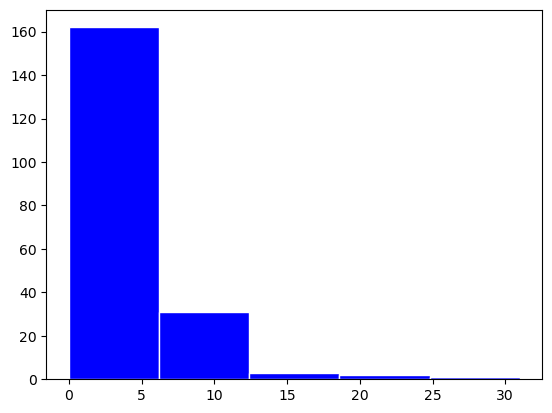

In [ ]:
plt.hist(employee_df[employee_df['AttritionNum']==1]['YearsAtCompany'], color='blue',edgecolor='white',bins=5)

In [ ]:
AvgYearsOfEmployees = employee_df[employee_df['Attrition'] == 'No' ].YearsAtCompany.mean()
AvgYearsOfAttritionEmployees = employee_df[ employee_df['Attrition'] == 'Yes' ].YearsAtCompany.mean()

NumOfYears = pd.DataFrame([ ['No',AvgYearsOfEmployees], ['Yes',AvgYearsOfAttritionEmployees] ], columns=['Attrition', 'Average Number of Years at Company'])
NumOfYears.set_index('Attrition', inplace=True)

NumOfYears

,Average Number of Years at Company
Attrition,
No,7.484089
Yes,3.688442


In [ ]:
NumOfYearsWithManager = employee_df[employee_df['Attrition'] == 'No' ].YearsWithCurrManager.mean()
NumOfYearsWithManagerAttrition = employee_df[employee_df['Attrition'] == 'Yes' ].YearsWithCurrManager.mean()

WithManager = pd.DataFrame([ ['No',NumOfYearsWithManager], ['Yes',NumOfYearsWithManagerAttrition] ], columns=['Attrition', 'Average Number Of Years with manager'])
WithManager.set_index('Attrition', inplace=True)

WithManager

,Average Number Of Years with manager
Attrition,
No,4.398104
Yes,2.185930


In [ ]:
AverageMonthlyIncome = employee_df[employee_df['Attrition'] == 'No' ].MonthlyIncome.mean()
AverageMonthlyIncomeAttrition = employee_df[employee_df['Attrition'] == 'Yes' ].MonthlyIncome.mean()

MonthlyIncome = pd.DataFrame([ ['No',AverageMonthlyIncome], ['Yes',AverageMonthlyIncomeAttrition] ], columns=['Attrition', 'Average Monthly Income'])
MonthlyIncome.set_index('Attrition', inplace=True)

MonthlyIncome

,Average Monthly Income
Attrition,
No,6852.301963
Yes,4024.246231


In [ ]:
AverageHourlyIncome = employee_df[employee_df['Attrition'] == 'No' ].HourlyRate.mean()
AverageHourlyIncomeAttrition = employee_df[employee_df['Attrition'] == 'Yes' ].HourlyRate.mean()

HourlyIncome = pd.DataFrame([ ['No',AverageHourlyIncome], ['Yes',AverageHourlyIncomeAttrition] ], columns=['Attrition', 'Average Hourly Income'])
HourlyIncome.set_index('Attrition', inplace=True)

HourlyIncome

,Average Hourly Income
Attrition,
No,65.739336
Yes,63.472362


In [ ]:
employee_attrition_df = employee_df[ employee_df['Attrition'] == 'Yes' ].copy()
employee_attrition_df

,EmployeeID,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,StandardHours,Shift,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AttritionNum
2,1060315,37,Yes,Travel_Rarely,1373,Maternity,2,2,Other,1,...,80,0,7,3,3,0,0,0,0,1
14,1420391,28,Yes,Travel_Rarely,103,Maternity,24,3,Life Sciences,1,...,80,0,6,4,3,4,2,0,3,1
26,1142062,32,Yes,Travel_Frequently,1125,Maternity,16,1,Life Sciences,1,...,80,0,10,5,3,10,2,6,7,1
34,1884939,24,Yes,Travel_Rarely,813,Maternity,1,3,Medical,1,...,80,1,6,2,2,2,0,2,0,1
36,1058169,50,Yes,Travel_Rarely,869,Cardiology,3,2,Marketing,1,...,80,0,3,2,3,3,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1667,1175959,28,Yes,Travel_Rarely,329,Neurology,24,3,Medical,1,...,80,3,1,3,3,1,1,0,0,1
1668,1655666,20,Yes,Travel_Frequently,871,Neurology,6,3,Life Sciences,1,...,80,0,1,5,3,1,0,1,0,1
1669,1602218,33,Yes,Travel_Rarely,1017,Maternity,25,3,Medical,1,...,80,0,5,0,3,2,2,2,2,1
1670,1336016,28,Yes,Travel_Rarely,654,Maternity,1,2,Life Sciences,1,...,80,0,10,4,3,7,7,3,7,1


<AxesSubplot:>

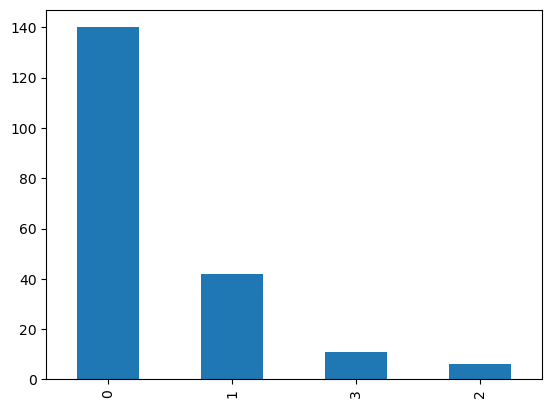

In [ ]:
employee_attrition_df.Shift.value_counts().plot(kind='bar')

<AxesSubplot:>

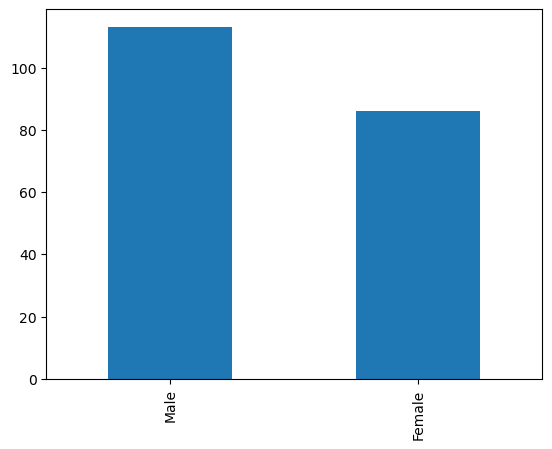

In [ ]:
employee_attrition_df.Gender.value_counts().plot(kind='bar')

In [ ]:
employee_df.dtypes

EmployeeID                   int64
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
Shift                        int64
TotalWorkingYears   

In [ ]:
employee_df=employee_df.drop(['Attrition','EmployeeID'], axis=1)

In [ ]:
column_names = ['BusinessTravel',
                       'Department',
                       'EducationField',
                       'Gender',
                       'JobRole',
                       'MaritalStatus',
                       'Over18',
                       'OverTime'
                      ]
int_cols = employee_df.drop(column_names, axis=1)
obj_columns = employee_df.filter(column_names, axis = 1)

In [ ]:
obj_columns_one_hot = pd.get_dummies(obj_columns, drop_first=True)
obj_columns_one_hot.shape

(1676, 17)

In [ ]:
employee_df_new = pd.concat([int_cols,obj_columns_one_hot], axis=1)

In [ ]:
X =  employee_df_new.drop(['AttritionNum'], axis=1)
Y = employee_df_new.filter(['AttritionNum'], axis=1)

In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.25,random_state=4)
X_train.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Administrative,JobRole_Nurse,JobRole_Other,JobRole_Therapist,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
1125,36,1302,6,4,1,1,80,4,2,1,...,0,0,1,0,1,0,0,1,0,1
888,44,1117,2,1,1,1,72,4,1,4,...,0,0,0,0,0,1,0,1,0,0
1417,47,1162,1,1,1,3,98,3,3,2,...,0,0,0,1,0,0,0,1,0,0
404,28,1300,17,2,1,3,79,3,2,1,...,0,0,1,0,1,0,0,0,0,0
1033,31,523,2,3,1,2,94,3,1,4,...,0,0,1,0,1,0,0,1,0,1


In [ ]:
Y.value_counts()

AttritionNum
0               1477
1                199
dtype: int64

In [ ]:
LR_clf=LogisticRegression(C = 0.1, random_state = 42, solver = 'liblinear')
DT_clf=DecisionTreeClassifier()
RF_clf=RandomForestClassifier()
GNB_clf=GaussianNB()
KNN_clf = KNeighborsClassifier(n_neighbors=3)
SVM_clf = svm.SVC(kernel='linear')

In [ ]:
LR_clf.fit(X_train,Y_train)
train_pred_LR=LR_clf.predict(X_train)
test_pred_LR=LR_clf.predict(X_test)
train_score=accuracy_score(Y_train,train_pred_LR)
test_score=accuracy_score(Y_test,test_pred_LR)
print("Logistic Regression training data accuracy is : %f" % (train_score))
print("Logistic Regression test data accuracy is : %f" % (test_score))

Logistic Regression training data accuracy is : 0.941130
Logistic Regression test data accuracy is : 0.916468


In [ ]:
print(classification_report(Y_test,test_pred_LR))


              precision    recall  f1-score   support

           0       0.93      0.98      0.95       371
           1       0.74      0.42      0.53        48

    accuracy                           0.92       419
   macro avg       0.83      0.70      0.74       419
weighted avg       0.91      0.92      0.91       419



In [ ]:
DT_clf.fit(X_train,Y_train)
train_pred_DT=DT_clf.predict(X_train)
test_pred_DT=DT_clf.predict(X_test)
train_score=accuracy_score(Y_train,train_pred_DT)
test_score=accuracy_score(Y_test,test_pred_DT)
print("Decision Tree training data accuracy is : %f" % (train_score))
print("Decision Tree test data accuracy is : %f" % (test_score))

Decision Tree training data accuracy is : 0.998409
Decision Tree test data accuracy is : 0.861575


In [ ]:
print(classification_report(Y_test,test_pred_DT))

              precision    recall  f1-score   support

           0       0.93      0.91      0.92       371
           1       0.41      0.48      0.44        48

    accuracy                           0.86       419
   macro avg       0.67      0.70      0.68       419
weighted avg       0.87      0.86      0.87       419



In [ ]:
RF_clf.fit(X_train,Y_train)
train_pred_RF=RF_clf.predict(X_train)
test_pred_RF=RF_clf.predict(X_test)
train_score=accuracy_score(Y_train,train_pred_RF)
test_score=accuracy_score(Y_test,test_pred_RF)
print("Random Forest training data accuracy is : %f" % (train_score))
print("Random Forest test data accuracy is : %f" % (test_score))

Random Forest training data accuracy is : 0.998409
Random Forest test data accuracy is : 0.894988


In [ ]:
print(classification_report(Y_test,test_pred_RF))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       371
           1       0.59      0.27      0.37        48

    accuracy                           0.89       419
   macro avg       0.75      0.62      0.66       419
weighted avg       0.88      0.89      0.88       419



<AxesSubplot:>

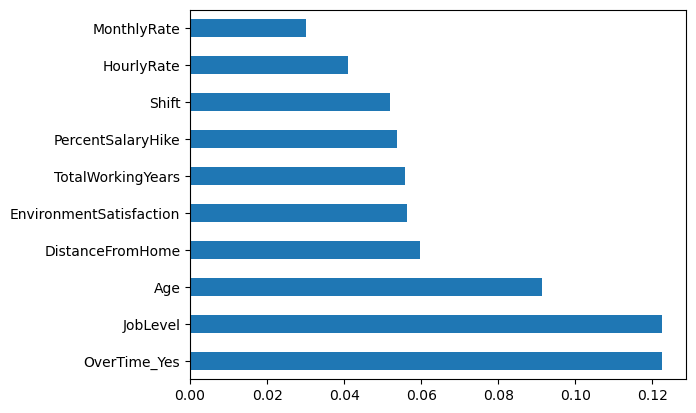

In [ ]:
sign_features_DT = pd.Series(DT_clf.feature_importances_, index=X.columns)
sign_features_DT.nlargest(10).plot(kind='barh')

<AxesSubplot:>

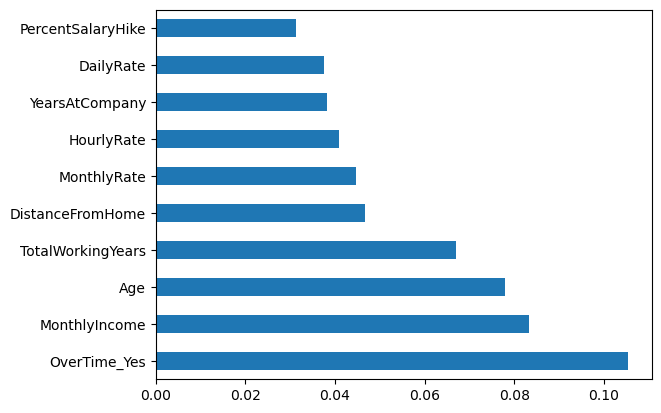

In [ ]:
sign_features_RF = pd.Series(RF_clf.feature_importances_, index=X.columns)
sign_features_RF.nlargest(10).plot(kind='barh')

In [ ]:
GNB_clf.fit(X_train,Y_train)
train_pred_GNB=GNB_clf.predict(X_train)
test_pred_GNB=GNB_clf.predict(X_test)
train_score=accuracy_score(Y_train,train_pred_GNB)
test_score=accuracy_score(Y_test,test_pred_GNB)
print("Gaussian Naive Bayes training data accuracy is : %f" % (train_score))
print("Gaussian Naive Bayes test data accuracy is : %f" % (test_score))

Gaussian Naive Bayes training data accuracy is : 0.710422
Gaussian Naive Bayes test data accuracy is : 0.699284


In [ ]:
print(classification_report(Y_test,test_pred_GNB))

              precision    recall  f1-score   support

           0       0.95      0.70      0.80       371
           1       0.23      0.71      0.35        48

    accuracy                           0.70       419
   macro avg       0.59      0.70      0.58       419
weighted avg       0.87      0.70      0.75       419



In [ ]:
KNN_clf.fit(X_train,Y_train)
train_pred_KNN=KNN_clf.predict(X_train)
test_pred_KNN=KNN_clf.predict(X_test)
train_score=accuracy_score(Y_train,train_pred_KNN)
test_score=accuracy_score(Y_test,test_pred_KNN)
print("K-Nearest Neighbor training data accuracy is : %f" % (train_score))
print("K-Nearest Neighbor test data accuracy is : %f" % (test_score))

K-Nearest Neighbor training data accuracy is : 0.922037
K-Nearest Neighbor test data accuracy is : 0.852029


In [ ]:
print(classification_report(Y_test,test_pred_KNN))

              precision    recall  f1-score   support

           0       0.90      0.94      0.92       371
           1       0.25      0.15      0.18        48

    accuracy                           0.85       419
   macro avg       0.57      0.54      0.55       419
weighted avg       0.82      0.85      0.83       419



In [ ]:
SVM_clf.fit(X_train,Y_train)
train_pred_SVM=SVM_clf.predict(X_train)
test_pred_SVM=SVM_clf.predict(X_test)
train_score=accuracy_score(Y_train,train_pred_SVM)
test_score=accuracy_score(Y_test,test_pred_SVM)
print("Support Vector Machine training data accuracy is : %f" % (train_score))
print("Support Vector Machine test data accuracy is : %f" % (test_score))

Support Vector Machine training data accuracy is : 0.916468
Support Vector Machine test data accuracy is : 0.892601


In [ ]:
print(classification_report(Y_test,test_pred_SVM))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       371
           1       0.57      0.27      0.37        48

    accuracy                           0.89       419
   macro avg       0.74      0.62      0.65       419
weighted avg       0.87      0.89      0.88       419



In [ ]:
accuracy_scores={'Logistic Regression':accuracy_score(Y_test,test_pred_LR),
             'KNN classifier':accuracy_score(Y_test,test_pred_KNN),
             'Support Vector Machine':accuracy_score(Y_test,test_pred_SVM),
             'Random forest':accuracy_score(Y_test,test_pred_RF),
              'Decision tree':accuracy_score(Y_test,test_pred_DT),
              'Naive Bayes':accuracy_score(Y_test,test_pred_GNB)
             }

In [ ]:
ml_compare=pd.DataFrame(accuracy_scores,index=['accuracy'])
ml_compare

,Logistic Regression,KNN classifier,Support Vector Machine,Random forest,Decision tree,Naive Bayes
accuracy,0.916468,0.852029,0.892601,0.894988,0.861575,0.699284


<AxesSubplot:>

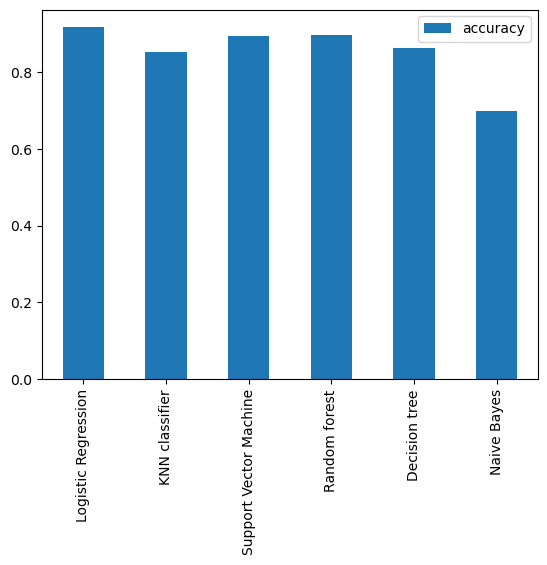

In [ ]:
ml_compare.T.plot(kind='bar')

In [ ]:
class_majority = employee_df_new[(employee_df_new['AttritionNum']==0)]
class_minority = employee_df_new[(employee_df_new['AttritionNum']==1)]
class_minority_upsampled = resample(class_minority,
                                 replace=True,
                                 n_samples= 1477,
                                 random_state=42)

df_upsampled = pd.concat([class_minority_upsampled, class_majority])

In [ ]:
X = df_upsampled.drop(['AttritionNum'], axis=1)
Y = df_upsampled.filter(['AttritionNum'], axis=1)

In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.25,random_state=4)
X_train.head()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Administrative,JobRole_Nurse,JobRole_Other,JobRole_Therapist,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
1532,39,505,2,4,1,3,64,3,3,3,...,0,1,0,0,0,1,0,0,1,0
1491,41,930,3,3,1,3,57,2,2,2,...,0,0,1,0,1,0,0,0,0,0
833,29,408,23,1,1,4,45,2,3,1,...,0,0,0,0,1,0,0,1,0,0
1434,23,638,9,3,1,4,33,3,1,1,...,0,0,1,0,0,1,0,1,0,0
403,41,645,1,3,1,2,49,4,3,1,...,0,0,1,0,1,0,0,1,0,0


In [ ]:
Y_train.value_counts()

AttritionNum
0               1112
1               1103
dtype: int64

In [ ]:
LR_clf.fit(X_train,Y_train)
train_pred_LR=LR_clf.predict(X_train)
test_pred_LR=LR_clf.predict(X_test)
train_score=accuracy_score(Y_train,train_pred_LR)
test_score=accuracy_score(Y_test,test_pred_LR)
print("Logistic Regression training data accuracy is : %f" % (train_score))
print("Logistic Regression test data accuracy is : %f" % (test_score))

Logistic Regression training data accuracy is : 0.889391
Logistic Regression test data accuracy is : 0.906631


In [ ]:
print(classification_report(Y_test,test_pred_LR))

              precision    recall  f1-score   support

           0       0.92      0.89      0.90       365
           1       0.90      0.92      0.91       374

    accuracy                           0.91       739
   macro avg       0.91      0.91      0.91       739
weighted avg       0.91      0.91      0.91       739



In [ ]:
DT_clf.fit(X_train,Y_train)
train_pred_DT=DT_clf.predict(X_train)
test_pred_DT=DT_clf.predict(X_test)
train_score=accuracy_score(Y_train,train_pred_DT)
test_score=accuracy_score(Y_test,test_pred_DT)
print("Decision Tree training data accuracy is : %f" % (train_score))
print("Decision Tree test data accuracy is : %f" % (test_score))

Decision Tree training data accuracy is : 0.996840
Decision Tree test data accuracy is : 0.968877


In [ ]:
print(classification_report(Y_test,test_pred_DT))

              precision    recall  f1-score   support

           0       1.00      0.94      0.97       365
           1       0.94      1.00      0.97       374

    accuracy                           0.97       739
   macro avg       0.97      0.97      0.97       739
weighted avg       0.97      0.97      0.97       739



In [ ]:
RF_clf.fit(X_train,Y_train)
train_pred_RF=RF_clf.predict(X_train)
test_pred_RF=RF_clf.predict(X_test)
train_score=accuracy_score(Y_train,train_pred_RF)
test_score=accuracy_score(Y_test,test_pred_RF)
print("Random Forest training data accuracy is : %f" % (train_score))
print("Random Forest test data accuracy is : %f" % (test_score))

Random Forest training data accuracy is : 0.996840
Random Forest test data accuracy is : 0.982409


In [ ]:
print(classification_report(Y_test,test_pred_RF))

              precision    recall  f1-score   support

           0       1.00      0.96      0.98       365
           1       0.97      1.00      0.98       374

    accuracy                           0.98       739
   macro avg       0.98      0.98      0.98       739
weighted avg       0.98      0.98      0.98       739



In [ ]:
GNB_clf.fit(X_train,Y_train)
train_pred_GNB=GNB_clf.predict(X_train)
test_pred_GNB=GNB_clf.predict(X_test)
train_score=accuracy_score(Y_train,train_pred_GNB)
test_score=accuracy_score(Y_test,test_pred_GNB)
print("Gaussian Naive Bayes training data accuracy is : %f" % (train_score))
print("Gaussian Naive Bayes test data accuracy is : %f" % (test_score))

Gaussian Naive Bayes training data accuracy is : 0.723702
Gaussian Naive Bayes test data accuracy is : 0.741543


In [ ]:
print(classification_report(Y_test,test_pred_GNB))

              precision    recall  f1-score   support

           0       0.83      0.60      0.70       365
           1       0.69      0.88      0.78       374

    accuracy                           0.74       739
   macro avg       0.76      0.74      0.74       739
weighted avg       0.76      0.74      0.74       739



In [ ]:
KNN_clf.fit(X_train,Y_train)
train_pred_KNN=KNN_clf.predict(X_train)
test_pred_KNN=KNN_clf.predict(X_test)
train_score=accuracy_score(Y_train,train_pred_KNN)
test_score=accuracy_score(Y_test,test_pred_KNN)
print("K-Nearest Neighbor training data accuracy is : %f" % (train_score))
print("K-Nearest Neighbor test data accuracy is : %f" % (test_score))

K-Nearest Neighbor training data accuracy is : 0.935440
K-Nearest Neighbor test data accuracy is : 0.887686


In [ ]:
print(classification_report(Y_test,test_pred_KNN))

              precision    recall  f1-score   support

           0       0.99      0.78      0.87       365
           1       0.82      0.99      0.90       374

    accuracy                           0.89       739
   macro avg       0.91      0.89      0.89       739
weighted avg       0.91      0.89      0.89       739



In [ ]:
SVM_clf.fit(X_train,Y_train)
train_pred_SVM=SVM_clf.predict(X_train)
test_pred_SVM=SVM_clf.predict(X_test)
train_score=accuracy_score(Y_train,train_pred_SVM)
test_score=accuracy_score(Y_test,test_pred_SVM)
print("Support Vector Machine training data accuracy is : %f" % (train_score))
print("Support Vector Machine test data accuracy is : %f" % (test_score))

Support Vector Machine training data accuracy is : 0.808126
Support Vector Machine test data accuracy is : 0.805142


In [ ]:
print(classification_report(Y_test,test_pred_SVM))

              precision    recall  f1-score   support

           0       0.85      0.74      0.79       365
           1       0.77      0.87      0.82       374

    accuracy                           0.81       739
   macro avg       0.81      0.80      0.80       739
weighted avg       0.81      0.81      0.80       739



In [ ]:
accuracy_scores={'Logistic Regression':accuracy_score(Y_test,test_pred_LR),
             'KNN classifier':accuracy_score(Y_test,test_pred_KNN),
             'Support Vector Machine':accuracy_score(Y_test,test_pred_SVM),
             'Random forest':accuracy_score(Y_test,test_pred_RF),
              'Decision tree':accuracy_score(Y_test,test_pred_DT),
              'Naive Bayes':accuracy_score(Y_test,test_pred_GNB)
             }

In [ ]:
ml_compare=pd.DataFrame(accuracy_scores,index=['accuracy'])
ml_compare

,Logistic Regression,KNN classifier,Support Vector Machine,Random forest,Decision tree,Naive Bayes
accuracy,0.906631,0.887686,0.805142,0.982409,0.968877,0.741543


<AxesSubplot:>

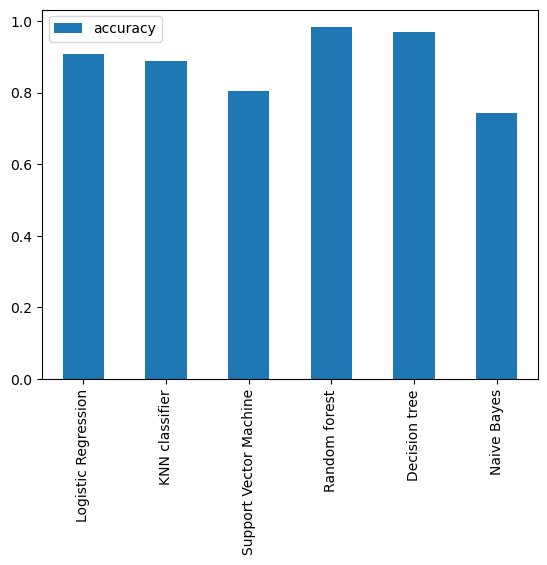

In [ ]:
ml_compare.T.plot(kind='bar')

In [ ]:
eli5.show_weights(DT_clf)

Weight,Feature
0.2167,x41
0.1244,x21
0.0944,x10
0.0888,x0
0.0787,x2
0.0590,x6
0.0522,x20
0.0405,x1
0.0328,x7
0.0321,x17


In [ ]:
eli5.show_prediction(DT_clf, X_train.iloc[1], feature_names = list(X.columns))

In [ ]:
eli5.show_weights(LR_clf)

In [ ]:
eli5.show_prediction(LR_clf, X_train.iloc[1], feature_names = list(X.columns))

In [ ]:
eli5.show_weights(RF_clf)

Weight,Feature
0.1342 ± 0.1029,x41
0.0869 ± 0.0998,x0
0.0721 ± 0.0948,x10
0.0582 ± 0.0975,x21
0.0536 ± 0.0816,x18
0.0453 ± 0.0408,x2
0.0381 ± 0.0920,x8
0.0363 ± 0.0349,x1
0.0332 ± 0.0675,x22
0.0331 ± 0.0682,x24


In [ ]:
eli5.show_prediction(RF_clf, X_train.iloc[1], feature_names = list(X.columns))

In [ ]:
eli5.show_weights(SVM_clf)

In [ ]:
eli5.show_prediction(SVM_clf, X_train.iloc[1], feature_names = list(X.columns))